In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
df=pd.read_csv("students_kmeans.csv")
df

,Student_ID,Study_Hours_Per_Day,Exam_Score
0,1,2.0,45
1,2,3.0,50
2,3,1.0,40
3,4,2.5,48
4,5,3.0,52
5,6,8.0,88
6,7,9.0,92
7,8,7.5,85
8,9,8.5,90
9,10,9.0,95


In [4]:
print(df.shape)
df.info()

(20, 3)
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           20 non-null     int64  
 1   Study_Hours_Per_Day  20 non-null     float64
 2   Exam_Score           20 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 612.0 bytes


In [6]:
x=df[["Study_Hours_Per_Day","Exam_Score"]]
x.head()

,Study_Hours_Per_Day,Exam_Score
0,2.0,45
1,3.0,50
2,1.0,40
3,2.5,48
4,3.0,52


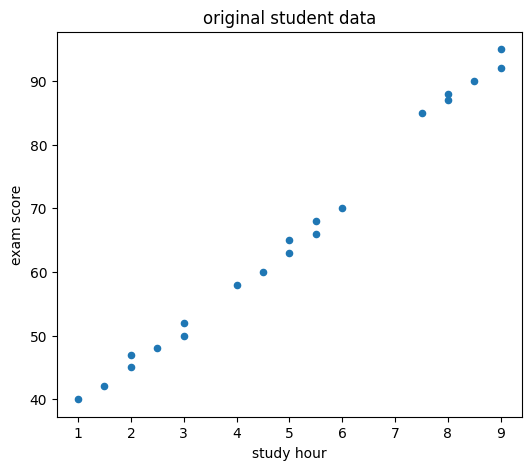

In [8]:
plt.figure(figsize=(6,5))

plt.scatter(x["Study_Hours_Per_Day"],x["Exam_Score"],s=20)

plt.xlabel("study hour")
plt.ylabel("exam score")
plt.title("original student data")

plt.show()

In [9]:
z=linkage(x,method="ward")
z

array([[  5.        ,  17.        ,   1.        ,   2.        ],
       [  3.        ,  16.        ,   1.11803399,   2.        ],
       [ 10.        ,  19.        ,   1.11803399,   2.        ],
       [  1.        ,   4.        ,   2.        ,   2.        ],
       [  2.        ,  15.        ,   2.06155281,   2.        ],
       [  6.        ,   8.        ,   2.06155281,   2.        ],
       [ 11.        ,  13.        ,   2.06155281,   2.        ],
       [ 12.        ,  18.        ,   2.06155281,   2.        ],
       [  0.        ,  21.        ,   2.9011492 ,   3.        ],
       [ 14.        ,  22.        ,   2.9011492 ,   3.        ],
       [  7.        ,  20.        ,   2.94392029,   3.        ],
       [  9.        ,  25.        ,   4.62781446,   3.        ],
       [ 27.        ,  29.        ,   6.77372374,   5.        ],
       [ 23.        ,  28.        ,   6.83617827,   5.        ],
       [ 30.        ,  31.        ,   9.96661093,   6.        ],
       [ 26.        ,  32

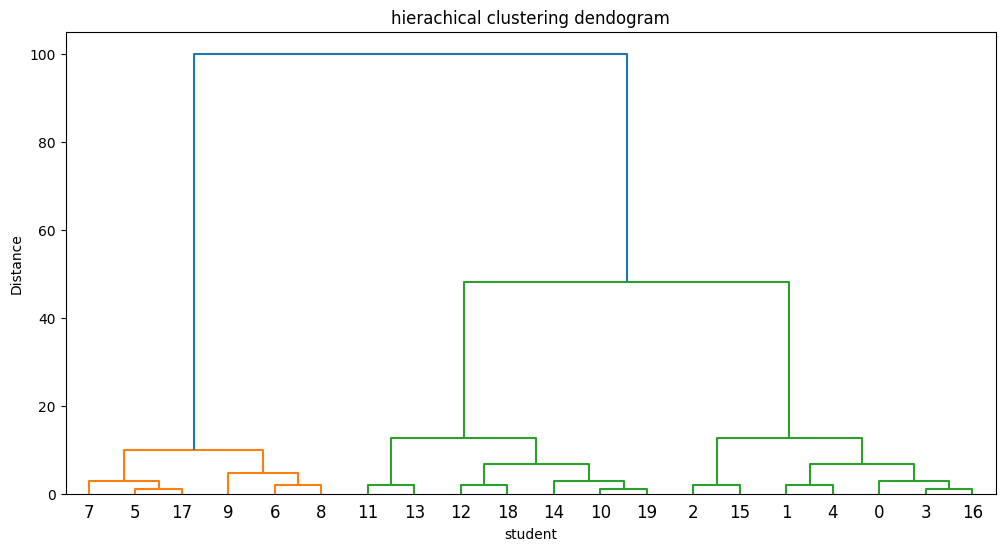

In [11]:
plt.figure(figsize=(12,6))

dendrogram(z)

plt.title("hierachical clustering dendogram")
plt.xlabel("student")
plt.ylabel("Distance")
plt.show()


In [12]:
from scipy.cluster.hierarchy import fcluster

cluster=fcluster(z,3,criterion="maxclust")
cluster

array([3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 1, 2, 2],
      dtype=int32)

In [13]:
df["cluster"]=cluster

df

,Student_ID,Study_Hours_Per_Day,Exam_Score,cluster
0,1,2.0,45,3
1,2,3.0,50,3
2,3,1.0,40,3
3,4,2.5,48,3
4,5,3.0,52,3
5,6,8.0,88,1
6,7,9.0,92,1
7,8,7.5,85,1
8,9,8.5,90,1
9,10,9.0,95,1
